In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../data/nlp_posts.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2091 entries, 0 to 2090
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.2      2091 non-null   int64  
 1   Unnamed: 0.1      2091 non-null   int64  
 2   Unnamed: 0        2091 non-null   int64  
 3   id                2091 non-null   object 
 4   title             2091 non-null   object 
 5   body              12 non-null     object 
 6   score             2091 non-null   int64  
 7   upvote_ratio      2091 non-null   float64
 8   num_comments      2091 non-null   int64  
 9   flair             2091 non-null   object 
 10  author            2091 non-null   object 
 11  url               2091 non-null   object 
 12  permalink         2091 non-null   object 
 13  created_utc       2091 non-null   object 
 14  category          2091 non-null   object 
 15  is_self_post      2091 non-null   bool   
 16  domain            2091 non-null   object 


In [4]:
df.shape

(2091, 27)

In [5]:
threshold = df["score"].quantile(0.75)
print(threshold)
df['Viral']=(df['score']>threshold).astype(int)

46179.0


In [6]:
df['Viral'].dtype

dtype('int64')

In [7]:
df['Viral'].value_counts()

Viral
0    1568
1     523
Name: count, dtype: int64

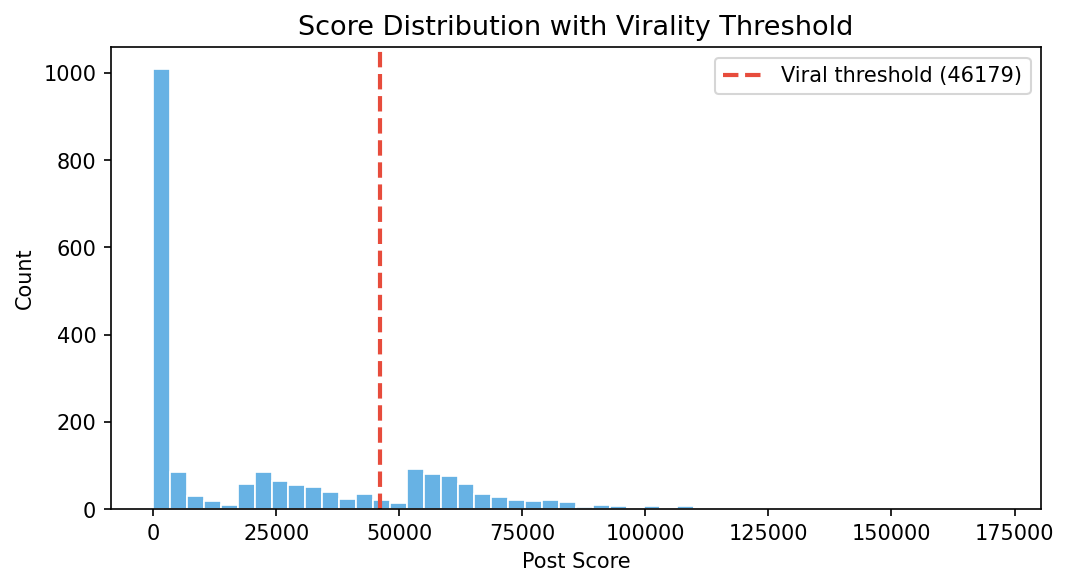

In [8]:
fig, ax = plt.subplots(figsize=(8, 4),dpi=150)
sns.histplot(data=df, x="score", bins=50, color="#3498db", edgecolor="white", ax=ax)
ax.axvline(threshold, color="#e74c3c", linestyle="--", linewidth=2, label=f"Viral threshold ({threshold:.0f})")
ax.set_title("Score Distribution with Virality Threshold", fontsize=13)
ax.set_xlabel("Post Score")
ax.legend()

In [9]:
df = df.drop(columns=[col for col in df.columns if "Unnamed" in col])

In [10]:
sentiment_map = {"positive": 1, "neutral": 0, "negative": -1}
df["sentiment_numeric"] = df["sentiment"].map(sentiment_map)

In [11]:
print(df[["sentiment", "sentiment_numeric", "confidence"]].head(20))

   sentiment  sentiment_numeric  confidence
0   negative                 -1      0.5265
1   negative                 -1      0.6667
2   negative                 -1      0.6376
3    neutral                  0      0.5808
4   negative                 -1      0.8899
5   negative                 -1      0.8146
6   negative                 -1      0.8778
7   negative                 -1      0.8693
8    neutral                  0      0.5175
9    neutral                  0      0.4442
10  negative                 -1      0.5865
11  negative                 -1      0.7082
12  positive                  1      0.6180
13  negative                 -1      0.6364
14  negative                 -1      0.8183
15  negative                 -1      0.7793
16   neutral                  0      0.4722
17  negative                 -1      0.8290
18  negative                 -1      0.9057
19  negative                 -1      0.8874


In [12]:
df["title_length"] = df["title"].fillna("").str.len()
df["title_word_count"] = df["title"].fillna("").str.split().str.len()
df["title_has_number"] = df["title"].fillna("").str.contains(r'\d').astype(int)
df["title_has_question"] =df["title"].fillna("").str.contains(r'\?').astype(int)
df["title_has_exclaim"] = df["title"].fillna("").str.contains(r'\!').astype(int)
df["has_comments_text"]= (df["top_comments"].fillna("").str.len() > 5).astype(int)

<Axes: xlabel='hour', ylabel='Count'>

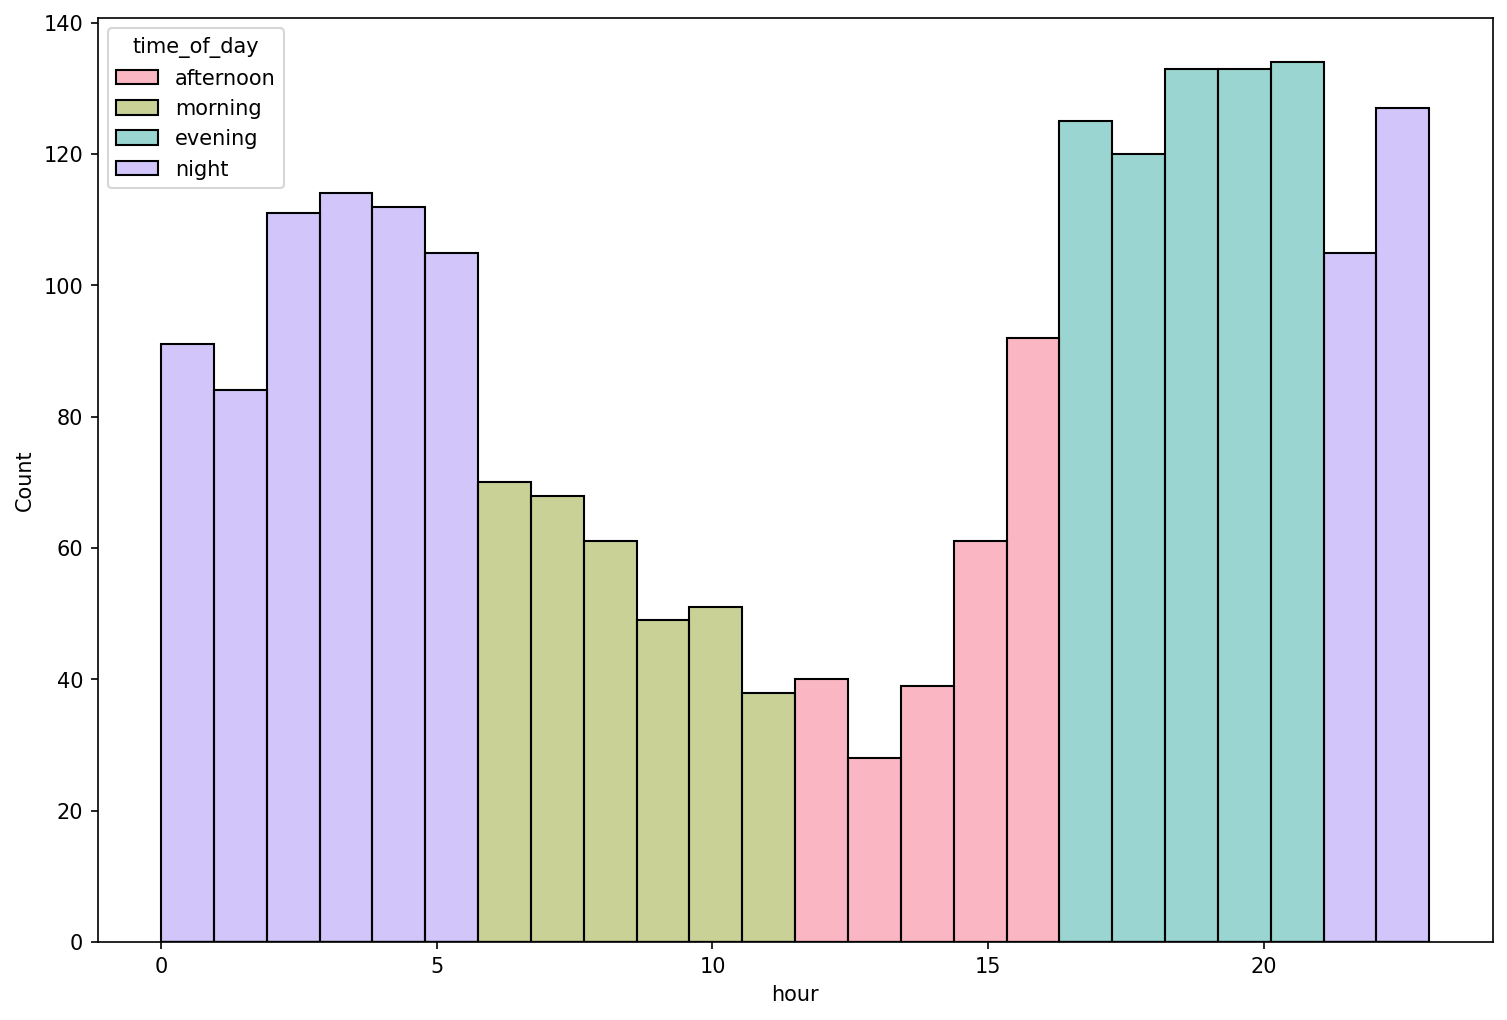

In [13]:
df["created_utc"] = pd.to_datetime(df["created_utc"])
df["hour"] = df["created_utc"].dt.hour
df["day_of_week"] = df["created_utc"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_peak_hour"] = df["hour"].between(8,22).astype(int)
def time_bucket(hour):
    if 6 <= hour < 12:   return "morning"
    elif 12 <= hour < 17: return "afternoon"
    elif 17 <= hour < 22: return "evening"
    else:                 return "night"

df["time_of_day"] = df["hour"].apply(time_bucket)
time_dummies = pd.get_dummies(df["time_of_day"], prefix="time")
plt.figure(figsize=(12,8),dpi=150)
sns.histplot(data=df,x="hour",hue="time_of_day",palette='husl',alpha=0.5,bins=24)


In [14]:
df = df.rename(columns={
    "Dominant_topics":  "dominant_topic",
    "topic_confidance": "topic_confidence",
    "Topic_labels":     "topic_label"
})
topic_dummies = pd.get_dummies(df["dominant_topic"], prefix="topic")
df["has_org_mention"]    = (df["orgs"].fillna("").str.len() > 0).astype(int)
df["org_mention_count"]  = df["orgs"].fillna("").str.split(" | ").apply(
                               lambda x: len([i for i in x if i.strip()])
                           )
df["has_person_mention"] = (df["persons"].fillna("").str.len() > 0).astype(int)

In [15]:
flair_counts = df["flair"].value_counts()
print(flair_counts)
common_flairs = flair_counts[flair_counts >= 5].index.tolist()
df["flair_clean"] = df["flair"].apply(
    lambda x: x if x in common_flairs else "Other"
)
flair_dummies = pd.get_dummies(df["flair_clean"], prefix="flair")
print(len(flair_dummies.columns))
print(df.groupby("flair_clean")["Viral"].mean().sort_values(ascending=False))

flair
Artificial Intelligence                  400
Business                                 398
Social Media                             216
Politics                                 185
Privacy                                  122
Hardware                                 109
Society                                   92
Security                                  90
Transportation                            89
Software                                  78
Net Neutrality                            55
Networking/Telecom                        48
Biotechnology                             48
Energy                                    32
Robotics/Automation                       23
Space                                     22
Misleading                                18
ADBLOCK WARNING                           13
Crypto                                     8
Machine Learning                           6
Nanotech/Materials                         5
Comcast                                    5
Disc

In [16]:
df["comment_score_ratio"] = (
    df["num_comments"] / (df["score"].replace(0, 1))
).round(4)
df["log_score"] = np.log1p(df["score"])
print(df[["score", "num_comments", "comment_score_ratio", "log_score"]].describe().round(2))
print(df.groupby("Viral")["comment_score_ratio"].mean().round(4))

           score  num_comments  comment_score_ratio  log_score
count    2091.00       2091.00              2091.00    2091.00
mean    23182.19       1180.45                 0.87       7.67
std     28622.74       1734.92                 5.82       3.39
min         0.00          0.00                 0.00       0.00
25%       157.00         27.50                 0.03       5.06
50%      4604.00        344.00                 0.07       8.43
75%     46179.00       1788.50                 0.15      10.74
max    171772.00      17957.00               190.00      12.05
Viral
0    1.1490
1    0.0492
Name: comment_score_ratio, dtype: float64


In [17]:
feature_matrix = pd.concat([
    # Sentiment — numeric only (no dummies, no redundancy)
    df[["sentiment_numeric", "confidence"]],
    # Title text features only (body dropped — 12/2091 non-null)
    df[["title_length", "title_word_count", "title_has_number",
        "title_has_question", "title_has_exclaim", "has_comments_text"]],
    # Time features — hour kept, time_dummies dropped (redundant with hour)
    df[["hour", "day_of_week", "is_weekend", "is_peak_hour"]],
    # Topic — confidence kept, dominant_topic numeric dropped
    # topic_dummies already encodes the topic info
    df[["topic_confidence"]],
    topic_dummies,
    # NER features
    df[["has_org_mention", "org_mention_count", "has_person_mention"]],
    
    # Flair
    flair_dummies,], axis=1)
y = df["Viral"]
print(f" {feature_matrix.shape}")
for col in feature_matrix.columns:
    print(f" {col}")

 (2091, 54)
 sentiment_numeric
 confidence
 title_length
 title_word_count
 title_has_number
 title_has_question
 title_has_exclaim
 has_comments_text
 hour
 day_of_week
 is_weekend
 is_peak_hour
 topic_confidence
 topic_1
 topic_2
 topic_3
 topic_4
 topic_5
 topic_6
 topic_7
 topic_8
 topic_9
 topic_10
 topic_11
 topic_12
 topic_13
 topic_14
 topic_15
 has_org_mention
 org_mention_count
 has_person_mention
 flair_ADBLOCK WARNING
 flair_Artificial Intelligence
 flair_Biotechnology
 flair_Business
 flair_Comcast
 flair_Crypto
 flair_Energy
 flair_Hardware
 flair_Machine Learning
 flair_Misleading
 flair_Nanotech/Materials
 flair_Net Neutrality
 flair_Networking/Telecom
 flair_Other
 flair_Politics
 flair_Privacy
 flair_Robotics/Automation
 flair_Security
 flair_Social Media
 flair_Society
 flair_Software
 flair_Space
 flair_Transportation


In [18]:
null_counts = feature_matrix.isnull().sum()
print(null_counts)

sentiment_numeric                0
confidence                       0
title_length                     0
title_word_count                 0
title_has_number                 0
title_has_question               0
title_has_exclaim                0
has_comments_text                0
hour                             0
day_of_week                      0
is_weekend                       0
is_peak_hour                     0
topic_confidence                 0
topic_1                          0
topic_2                          0
topic_3                          0
topic_4                          0
topic_5                          0
topic_6                          0
topic_7                          0
topic_8                          0
topic_9                          0
topic_10                         0
topic_11                         0
topic_12                         0
topic_13                         0
topic_14                         0
topic_15                         0
has_org_mention     

In [19]:
correlations = feature_matrix.corrwith(y).abs().sort_values(ascending=False)
correlations

flair_Artificial Intelligence    0.252814
flair_Net Neutrality             0.208685
flair_Other                      0.195899
flair_Social Media               0.137782
topic_8                          0.132750
has_comments_text                0.118676
flair_Hardware                   0.100663
title_length                     0.094784
flair_Politics                   0.088378
topic_2                          0.086435
flair_Business                   0.085661
flair_Comcast                    0.084772
title_word_count                 0.084364
topic_3                          0.078744
flair_Misleading                 0.077672
sentiment_numeric                0.075310
flair_Biotechnology              0.066404
title_has_exclaim                0.047371
topic_13                         0.045208
flair_Transportation             0.045187
flair_Software                   0.043758
flair_Robotics/Automation        0.039732
topic_confidence                 0.037156
flair_Crypto                     0

In [20]:
correlations.head(15)

flair_Artificial Intelligence    0.252814
flair_Net Neutrality             0.208685
flair_Other                      0.195899
flair_Social Media               0.137782
topic_8                          0.132750
has_comments_text                0.118676
flair_Hardware                   0.100663
title_length                     0.094784
flair_Politics                   0.088378
topic_2                          0.086435
flair_Business                   0.085661
flair_Comcast                    0.084772
title_word_count                 0.084364
topic_3                          0.078744
flair_Misleading                 0.077672
dtype: float64

Text(0, 0.5, 'Features')

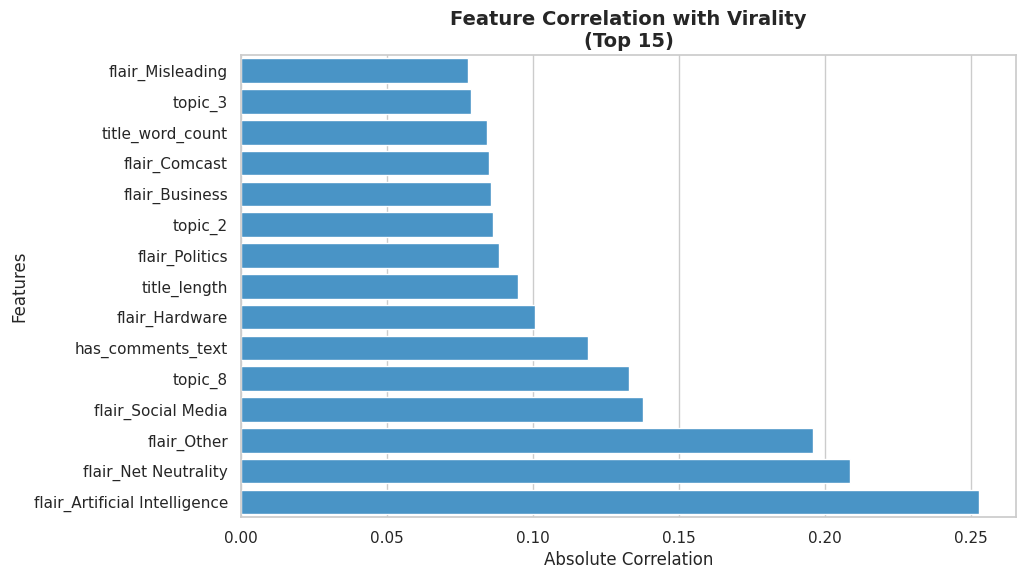

In [21]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
top_corr = correlations.head(15).sort_values()
sns.barplot(
    x=top_corr.values, 
    y=top_corr.index, 
    color="#3498db",
    edgecolor="white"
)

plt.title("Feature Correlation with Virality\n(Top 15)", fontsize=14, weight='bold')
plt.xlabel("Absolute Correlation", fontsize=12)
plt.ylabel("Features")

In [22]:
feature_matrix["viral"] = y.values
feature_matrix.to_csv("../data/feature_matrix.csv", index=False)
df.to_csv("../data/nlp_posts_fe.csv", index=False)